In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
# promeni ime fajla ako je drugačije
df = pd.read_excel("ANFIS.xlsx")

# koristimo samo ulaze i izlaz
X = df[["Coop", "Adap", "Forg", "Stoch"]].values
y = df["Output"].values.reshape(-1,1)

# ============================
# 2. NORMALIZACIJA
# ============================

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

Xn = scaler_X.fit_transform(X)
yn = scaler_y.fit_transform(y)

# ============================
# 3. PODELA NA TRAIN/TEST
# ============================

X_train, X_test, y_train, y_test = train_test_split(Xn, yn, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

# ============================
# 4. DEFINICIJA ANFIS MODEL
# ============================

class GaussianMF(nn.Module):
    def __init__(self, c, sigma):
        super().__init__()
        self.c = nn.Parameter(torch.tensor(float(c)))
        self.sigma = nn.Parameter(torch.tensor(float(sigma)))
    def forward(self, x):
        return torch.exp(-0.5 * ((x - self.c) / self.sigma)**2)

class ANFIS(nn.Module):
    def __init__(self, n_inputs, mfs_per_input):
        super().__init__()
        self.n_inputs = n_inputs
        self.m = mfs_per_input
        
        # membership functions: list of list of GaussianMF
        self.mf_layer = nn.ModuleList([
            nn.ModuleList([GaussianMF(0.5, 0.2) for _ in range(mfs_per_input)])
            for _ in range(n_inputs)
        ])
        
        # number of rules
        self.n_rules = mfs_per_input ** n_inputs
        
        # Sugeno linear consequents
        self.linear = nn.Linear(n_inputs, self.n_rules, bias=True)

    def forward(self, x):
        batch_size = x.size(0)

        # membership shape: [batch, input, mf]
        memberships = torch.stack([
            torch.stack([mf(x[:, i]) for mf in self.mf_layer[i]], dim=-1)
            for i in range(self.n_inputs)
        ], dim=1)

        # rule strength = product of membership values
        rule_strengths = memberships[:,0,:]
        for i in range(1, self.n_inputs):
            rule_strengths = rule_strengths.unsqueeze(2) * memberships[:,i,:].unsqueeze(1)
            rule_strengths = rule_strengths.reshape(batch_size, -1)

        w_normalized = rule_strengths / (rule_strengths.sum(dim=1, keepdim=True) + 1e-6)

        linear_output = self.linear(x)  # [batch, n_rules]
        output = (w_normalized * linear_output).sum(dim=1, keepdim=True)
        return output

In [ ]:
n_inputs = 4
mfs_per_input = 3

model = ANFIS(n_inputs=n_inputs, mfs_per_input=mfs_per_input)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

epochs = 50
batch_size = 512

loss_history = []

for epoch in range(epochs):
    perm = torch.randperm(X_train.size(0))
    epoch_loss = 0
    for i in range(0, X_train.size(0), batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train[idx]
        yb = y_train[idx]

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= X_train.size(0)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}")

Epoch 1/50, Loss: 0.379748
Epoch 2/50, Loss: 0.182713
Epoch 3/50, Loss: 0.109551
Epoch 4/50, Loss: 0.078370
Epoch 5/50, Loss: 0.069558
Epoch 6/50, Loss: 0.064013
Epoch 7/50, Loss: 0.060739
Epoch 8/50, Loss: 0.058349
Epoch 9/50, Loss: 0.056176
Epoch 10/50, Loss: 0.053986
Epoch 11/50, Loss: 0.051853
Epoch 12/50, Loss: 0.050329
Epoch 13/50, Loss: 0.049243
Epoch 14/50, Loss: 0.048413
Epoch 15/50, Loss: 0.047617
Epoch 16/50, Loss: 0.046955
Epoch 17/50, Loss: 0.046365
Epoch 18/50, Loss: 0.045888
Epoch 19/50, Loss: 0.045312
Epoch 20/50, Loss: 0.044808
Epoch 21/50, Loss: 0.044354
Epoch 22/50, Loss: 0.043816
Epoch 23/50, Loss: 0.043530
Epoch 24/50, Loss: 0.043049
Epoch 25/50, Loss: 0.042563
Epoch 26/50, Loss: 0.042249
Epoch 27/50, Loss: 0.041888
Epoch 28/50, Loss: 0.041611
Epoch 29/50, Loss: 0.041253
Epoch 30/50, Loss: 0.040979
Epoch 31/50, Loss: 0.040694
Epoch 32/50, Loss: 0.040321
Epoch 33/50, Loss: 0.040019
Epoch 34/50, Loss: 0.039936
Epoch 35/50, Loss: 0.039497
Epoch 36/50, Loss: 0.039331
E

RMSE na test setu: 0.16586574910378202


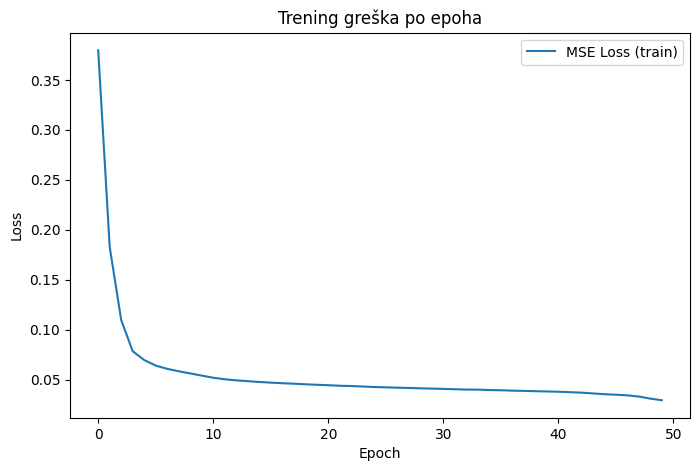

In [4]:
with torch.no_grad():
    y_pred = model(X_test).numpy()

y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_test_rescaled = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(np.mean((y_test_rescaled - y_pred_rescaled)**2))
print("RMSE na test setu:", rmse)

# ============================
# 7. GRAFIK GREŠKE
# ============================

plt.figure(figsize=(8,5))
plt.plot(loss_history, label="MSE Loss (train)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Trening greška po epoha")
plt.legend()
plt.show()

In [6]:
import joblib  # za čuvanje skalera

torch.save(model.state_dict(), "anfis_model.pt")
joblib.dump(scaler_X, "scaler_X.save")
joblib.dump(scaler_y, "scaler_y.save")


['scaler_y.save']